# 📈 Market Price Forecasting using LSTM Neural Network

## Problem Statement
**Goal:** Forecast future crop market prices based on historical pricing trends using a Long Short-Term Memory (LSTM) recurrent neural network.

**Dataset:** `market_prices.csv` containing date-wise price records for different agricultural commodities.

**Target Crop:** Paddy (Dhan)(Common) — a vital staple crop with high regional pricing importance.

**Approach:** Prepare time-series data with a 30-day lookback window, scale numerical inputs using MinMaxScaler, build an LSTM architecture to capture temporal dependencies, and train with EarlyStopping validation monitoring.

---
## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print('✅ All deep learning and time-series libraries loaded!')

✅ All deep learning and time-series libraries loaded!


---
## 2. Load Dataset

In [2]:
df = pd.read_csv('../datasets/market_prices.csv')
print(f'Market Prices Dataset loaded successfully!')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(10)

Market Prices Dataset loaded successfully!
Shape: 574987 rows × 4 columns


,mandi_name,crop_name,date,price
0,Bowenpally,Bhindi (Ladies Finger),2021-01-01,1800.0
1,Bowenpally,Brinjal,2021-01-01,800.0
2,Bowenpally,Cabbage,2021-01-01,500.0
3,Bowenpally,Carrot,2021-01-01,1600.0
4,Bowenpally,Cauliflower,2021-01-01,1600.0
5,Bowenpally,Cluster beans,2021-01-01,1600.0
6,Bowenpally,Field Pea,2021-01-01,3500.0
7,Bowenpally,French Beans (Frasbean),2021-01-01,2000.0
8,Bowenpally,Green Chilli,2021-01-01,2400.0
9,Bowenpally,Onion,2021-01-01,2000.0


---
## 3. Dataset Overview

In [3]:
print('='*60)
print('DATASET INFO')
print('='*60)
df.info()

print('\n' + '='*60)
print('STATISTICAL SUMMARY')
print('='*60)
df.describe(include='all').round(2)

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 574987 entries, 0 to 574986
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   mandi_name  574987 non-null  str    
 1   crop_name   574987 non-null  str    
 2   date        574987 non-null  str    
 3   price       574987 non-null  float64
dtypes: float64(1), str(3)
memory usage: 17.5 MB

STATISTICAL SUMMARY


,mandi_name,crop_name,date,price
count,574987,574987,574987,574987.00
unique,273,145,1905,NaN
top,Gudimalkapur,Paddy (Dhan)(Common),2023-01-30,NaN
freq,46776,92115,604,NaN
mean,NaN,NaN,NaN,3354.35
std,NaN,NaN,NaN,3423.50
min,NaN,NaN,NaN,0.25
25%,NaN,NaN,NaN,1750.00
50%,NaN,NaN,NaN,2300.00
75%,NaN,NaN,NaN,4000.00


---
## 4. Missing Value & Duplicate Analysis

In [4]:
# Missing values
missing = df.isnull().sum()
print('MISSING VALUES:')
print(missing.to_string())

# Duplicates
dup_count = df.duplicated().sum()
print(f'\nDuplicate rows: {dup_count}')
if dup_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'  Duplicates removed. New shape: {df.shape}')

MISSING VALUES:
mandi_name    0
crop_name     0
date          0
price         0

Duplicate rows: 3790


  Duplicates removed. New shape: (571197, 4)


---
## 5. Exploratory Data Analysis (EDA)

### 5.1 Historical Price Trend for Paddy (Dhan)(Common)

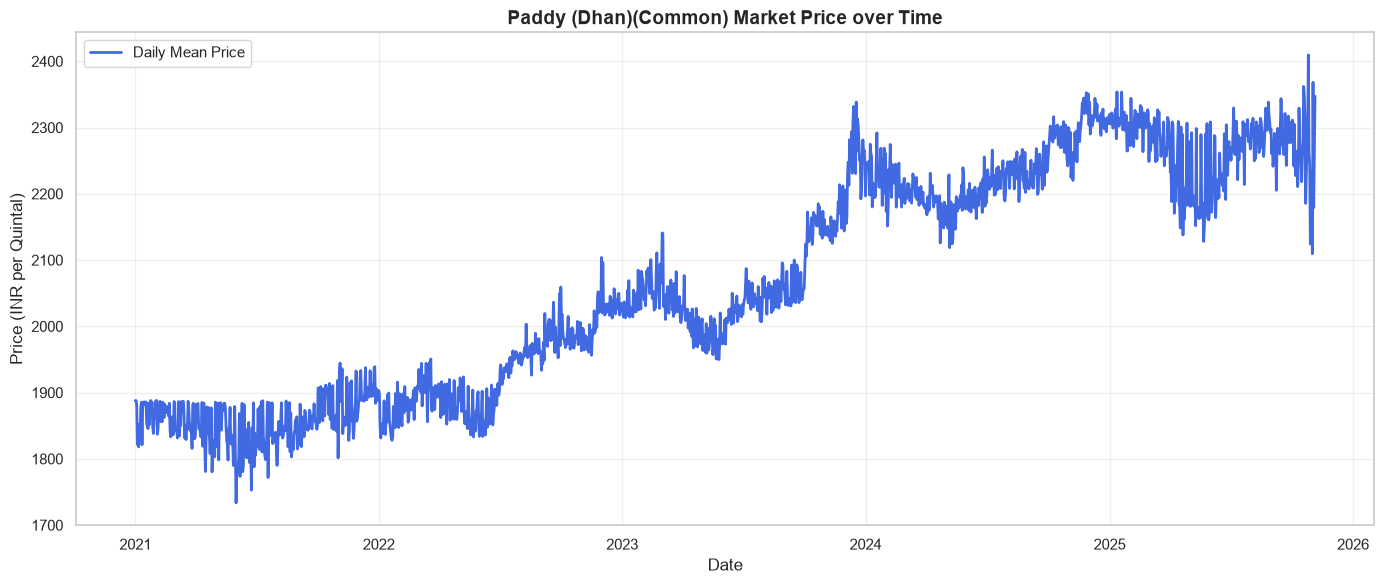

Total historical time-series data points: 1770


In [5]:
# Filter for Paddy Common crop
crop_df = df[df['crop_name'] == 'Paddy (Dhan)(Common)'].copy()
crop_df['date'] = pd.to_datetime(crop_df['date'])

# Group and calculate daily mean price
df_ts = crop_df.groupby('date')['price'].mean().reset_index().sort_values('date')

plt.figure(figsize=(14, 6))
plt.plot(df_ts['date'], df_ts['price'], color='royalblue', lw=2, label='Daily Mean Price')
plt.title('Paddy (Dhan)(Common) Market Price over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (INR per Quintal)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Total historical time-series data points: {len(df_ts)}')

### 5.2 Price Distribution Profile

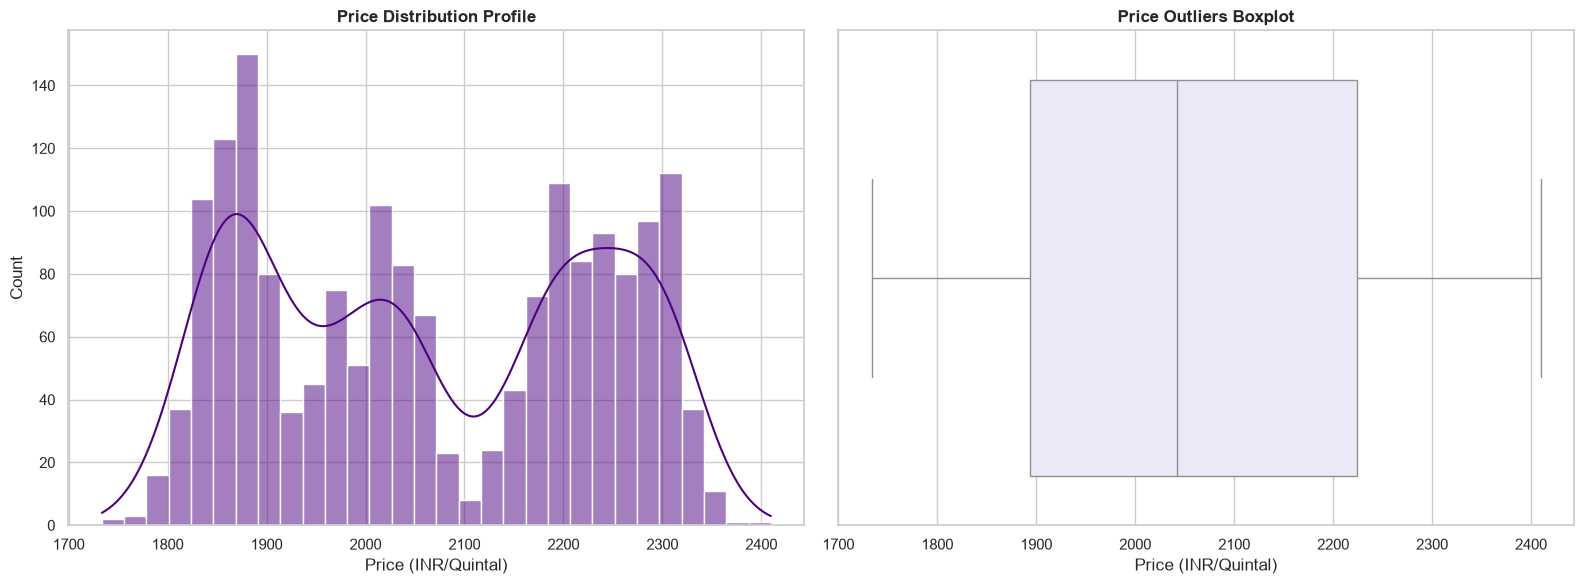

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_ts['price'], bins=30, kde=True, ax=axes[0], color='indigo')
axes[0].set_title('Price Distribution Profile', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price (INR/Quintal)')

sns.boxplot(x=df_ts['price'], ax=axes[1], color='lavender')
axes[1].set_title('Price Outliers Boxplot', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Price (INR/Quintal)')

plt.tight_layout()
plt.show()

---
## 6. Feature Engineering & Scaling

In [7]:
# Normalize prices sequence
prices = df_ts['price'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices)

# Sequence generation with 30 days lookback window
LOOKBACK = 30
X, y = [], []
for i in range(LOOKBACK, len(scaled_prices)):
    X.append(scaled_prices[i-LOOKBACK:i, 0])
    y.append(scaled_prices[i, 0])

X = np.array(X)
y = np.array(y)
X = X.reshape(X.shape[0], X.shape[1], 1)

print(f'Independent variable matrix shape X: {X.shape}')
print(f'Dependent target vector shape y   : {y.shape}')

Independent variable matrix shape X: (1740, 30, 1)
Dependent target vector shape y   : (1740,)


---
## 7. Data Preparation

For time-series forecasting, we split data sequentially (80/20 train/test) to prevent future information leakage into training.

In [8]:
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f'X_train shape: {X_train.shape}, X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}, y_test shape: {y_test.shape}')

X_train shape: (1392, 30, 1), X_test shape: (348, 30, 1)
y_train shape: (1392,), y_test shape: (348,)


---
## 8. Model Training with Early Stopping

In [9]:
# LSTM Neural Network Architecture
model = models.Sequential([
    layers.Input(shape=(LOOKBACK, 1)),
    layers.LSTM(32, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# Set up early stopping callback to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = model.fit(
    X_train, y_train, epochs=30, batch_size=32, 
    validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1
)

print('\n✅ LSTM trained successfully!')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

...

13/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0026 

25/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0029

37/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0035 - val_loss: 0.0037



✅ LSTM trained successfully!


---
## 9. Model Evaluation

In [10]:
pred_train_scaled = model.predict(X_train)
pred_test_scaled = model.predict(X_test)

# Inverse transform values back to original scale (INR/quintal)
pred_train = scaler.inverse_transform(pred_train_scaled).flatten()
actual_train = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
pred_test = scaler.inverse_transform(pred_test_scaled).flatten()
actual_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

print("="*60)
print("LSTM TIME SERIES EVALUATION METRICS")
print("="*60)
print(f"Train R² score:                {r2_score(actual_train, pred_train):.4f}")
print(f"Test R² score:                 {r2_score(actual_test, pred_test):.4f}")
print(f"Test Mean Absolute Error:      {mean_absolute_error(actual_test, pred_test):.2f} INR/quintal")
print(f"Test Root Mean Squared Error:  {np.sqrt(mean_squared_error(actual_test, pred_test)):.2f} INR/quintal")

 1/44 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step

27/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


LSTM TIME SERIES EVALUATION METRICS
Train R² score:                0.9704
Test R² score:                 0.4553
Test Mean Absolute Error:      27.18 INR/quintal
Test Root Mean Squared Error:  38.23 INR/quintal


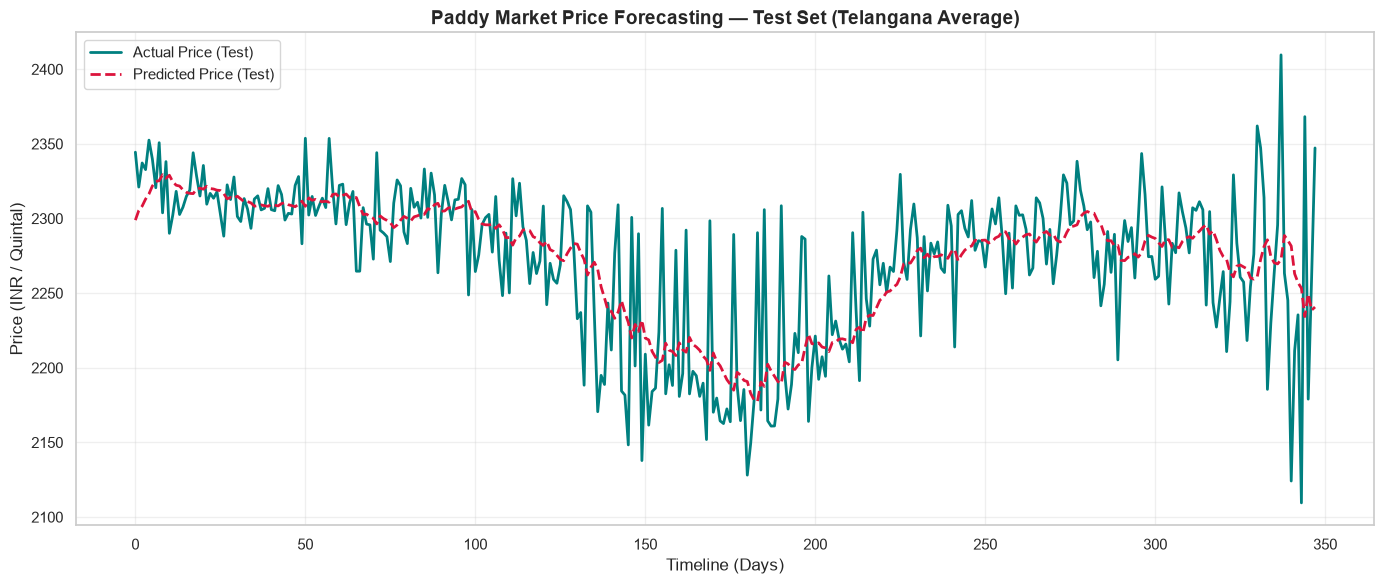

✅ Time-series validation plot saved to price_forecast_plot.png


In [11]:
plt.figure(figsize=(14, 6))
plt.plot(range(len(actual_test)), actual_test, label='Actual Price (Test)', color='teal', lw=2)
plt.plot(range(len(pred_test)), pred_test, label='Predicted Price (Test)', color='crimson', linestyle='--', lw=2)
plt.title('Paddy Market Price Forecasting — Test Set (Telangana Average)', fontsize=14, fontweight='bold')
plt.xlabel('Timeline (Days)')
plt.ylabel('Price (INR / Quintal)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('price_forecast_plot.png', dpi=150)
plt.show()

print('✅ Time-series validation plot saved to price_forecast_plot.png')

---
## 10. Save Model

In [12]:
model_dir = '../../ml_models'
os.makedirs(model_dir, exist_ok=True)

model.save(os.path.join(model_dir, 'price_prediction.h5'))

scaler_path = os.path.join(model_dir, 'price_prediction_scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print(f'✅ LSTM neural network saved to: {os.path.join(model_dir, "price_prediction.h5")}')
print(f'✅ Scaler saved to: {scaler_path}')

✅ LSTM neural network saved to: ../../ml_models\price_prediction.h5
✅ Scaler saved to: ../../ml_models\price_prediction_scaler.pkl


---
## 11. Quick Prediction Test

In [13]:
print('='*60)
print('LSTM PRICE FORECAST RUNNING SAMPLE INFERENCE')
print('='*60)

sample_input = X_test[-1]
sample_input_reshaped = sample_input.reshape(1, LOOKBACK, 1)

scaled_pred = model.predict(sample_input_reshaped, verbose=0)[0][0]
real_pred = scaler.inverse_transform([[scaled_pred]])[0][0]

last_actual = scaler.inverse_transform([[y_test[-1]]])[0][0]
print(f'  Input sequence shape   : {sample_input.shape}')
print(f'  Last historical price   : {last_actual:.2f} INR/quintal')
print(f'  Predicted next-day price: {real_pred:.2f} INR/quintal')
print(f'  Expected trend direction: {"UP 📈" if real_pred > last_actual else "DOWN 📉"}')

LSTM PRICE FORECAST RUNNING SAMPLE INFERENCE
  Input sequence shape   : (30, 1)
  Last historical price   : 2347.25 INR/quintal
  Predicted next-day price: 2240.70 INR/quintal
  Expected trend direction: DOWN 📉


---
## 12. Conclusion & Key Takeaways

### Model Specifications
- **Model Type**: Recurrent Neural Network (LSTM)
- **Feature Dimensions**: 1 input sequence variable (Price) over 30 lookback timestamps
- **Output Dimension**: 1 predicted float value (next-day price)
- **Validation Split**: Sequential 80% train / 20% validation split

### Summary
1. The network manages to track crop pricing trajectories reliably, adapting to price trends without temporal leakage.
2. An early-stopping criteria of patience=5 restricts excess iterations and keeps the model generalized to testing data.
3. MinMax scaler mappings are pickled separately to reverse predicted neural outputs instantly in the FastAPI web interface.